<a href="https://colab.research.google.com/github/titlibasu/html1/blob/main/Project(BCT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sayantanibasu","key":"17d35b55cf9e6e7b9146b16e55492e71"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d arnabchaki/indian-restaurants-2023

Dataset URL: https://www.kaggle.com/datasets/arnabchaki/indian-restaurants-2023
License(s): DbCL-1.0
100% 139k/139k [00:00<00:00, 374kB/s]



In [ ]:
import zipfile

In [ ]:
with zipfile.ZipFile("/content/indian-restaurants-2023.zip") as z:
  z.extractall("RESTAURANTS")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import seaborn as sns
import sklearn
import scipy.stats
from sklearn.impute import SimpleImputer

In [ ]:
data=pd.read_csv("/content/RESTAURANTS/restaurants.csv")
df=pd.DataFrame(data)
df

,Name,Location,Locality,City,Cuisine,Rating,Votes,Cost
0,Local,"Scindia House,Connaught Place, Central Delhi",Central Delhi,Delhi,"North Indian, Finger Food, Continental",4.1,2415,2000
1,The G.T. ROAD,"M-Block,Connaught Place, Central Delhi",Central Delhi,Delhi,North Indian,4.3,2363,1500
2,Tamasha,"Connaught Place, Central Delhi",Central Delhi,Delhi,"Finger Food, North Indian, Italian, Contine...",4.2,5016,2000
3,The Junkyard Cafe,"Connaught Place, Central Delhi",Central Delhi,Delhi,"North Indian, Mediterranean, Asian, Italian...",4.2,2821,1800
4,Chili's American Grill and Bar,"M-Block,Connaught Place, Central Delhi",Central Delhi,Delhi,"Mexican, American, Italian",4.4,1094,2000
...,...,...,...,...,...,...,...,...
6588,Shree Rathnam,"Wave Mall,BRS Nagar, West Ludhiana",West Ludhiana,Ludhiana,South Indian,4.1,20,600
6589,Cafe Delish,"Radisson Blu,Rajguru Nagar, West Ludhiana",West Ludhiana,Ludhiana,"Multi-Cuisine, North Indian, Continental, A...",4.4,48,3100
6590,3 K Resorts,"BRS Nagar, West Ludhiana",West Ludhiana,Ludhiana,North Indian,1.0,1,1100
6591,Dovka Bar,"Nirvana Hotel Banquets Club,PAU, Central Ludhiana",Central Ludhiana,Ludhiana,"North Indian, Chinese, Finger Food",4.3,3,1500


In [ ]:
df.shape

(6593, 8)

In [ ]:
df.size

52744

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6593 entries, 0 to 6592
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      6593 non-null   object 
 1   Location  6593 non-null   object 
 2   Locality  6593 non-null   object 
 3   City      6593 non-null   object 
 4   Cuisine   6593 non-null   object 
 5   Rating    6593 non-null   float64
 6   Votes     6593 non-null   int64  
 7   Cost      6593 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 412.2+ KB


In [ ]:
df.describe()

,Rating,Votes,Cost
count,6593.000000,6593.000000,6593.000000
mean,4.088200,119.420143,1102.798271
std,0.670031,261.849704,716.935212
min,1.000000,1.000000,100.000000
25%,3.900000,6.000000,500.000000
50%,4.200000,31.000000,900.000000
75%,4.400000,115.000000,1500.000000
max,5.000000,5016.000000,8000.000000


In [ ]:
df.isnull().sum()

,0
Name,0
Location,0
Locality,0
City,0
Cuisine,0
Rating,0
Votes,0
Cost,0


In [ ]:
# Filter restaurants with rating < 4.4
filtered_restaurants = df[df['Rating']< 4.4]
# Sort by rating in descending order
sorted_restaurants = filtered_restaurants.sort_values(by='Rating', ascending=False)

# Display the result
result= sorted_restaurants[['Name', 'Rating']]
result
result_df= result.reset_index(drop=True)
result_df

,Name,Rating
0,Dovka Bar,4.3
1,Hong Kong II,4.3
2,Cafe Hawkers,4.3
3,Kylin Experience,4.3
4,Shakti - The Sandwich Shop,4.3
...,...,...
4352,Subway,1.0
4353,Dumpling Hood,1.0
4354,Cake Waves,1.0
4355,G Dada,1.0


In [ ]:
# Filter restaurants with rating = 4.4
filtered_restaurants1 = df[df['Rating']== 4.4]
# Sort by rating in descending order
sorted_restaurants1 = filtered_restaurants1.sort_values(by='Rating', ascending=False)

# Display the result
result1 = sorted_restaurants1[['Name', 'Rating']]
result1
result1_df= result1.reset_index(drop=True)
result1_df

,Name,Rating
0,Cafe Delish,4.4
1,Chili's American Grill and Bar,4.4
2,Tamra,4.4
3,Cafe Delhi Heights,4.4
4,The Imperial Spice,4.4
...,...,...
676,MGM Club,4.4
677,Veg Gulati,4.4
678,Cafe Delhi Heights,4.4
679,Pindi,4.4


In [ ]:
# Filter restaurants with rating = 4.5
filtered_restaurants2 = df[df['Rating']== 4.5]
# Sort by rating in descending order
sorted_restaurants2 = filtered_restaurants2.sort_values(by='Rating', ascending=False)

# Display the result
result2 = sorted_restaurants1[['Name', 'Rating']]
result2
result2_df= result2.reset_index(drop=True)
result2_df

,Name,Rating
0,Cafe Delish,4.4
1,Chili's American Grill and Bar,4.4
2,Tamra,4.4
3,Cafe Delhi Heights,4.4
4,The Imperial Spice,4.4
...,...,...
676,MGM Club,4.4
677,Veg Gulati,4.4
678,Cafe Delhi Heights,4.4
679,Pindi,4.4


In [ ]:
# Filter restaurants with rating = 5.0
filtered_restaurants3 = df[df['Rating']== 5.0]
# Sort by rating in descending order
sorted_restaurants3 = filtered_restaurants3.sort_values(by='Rating', ascending=False)

# Display the result
result3 = sorted_restaurants3[['Name', 'Rating']]
result3
result3_df= result3.reset_index(drop=True)
result3_df

,Name,Rating
0,The Crispy Hawkers,5.0
1,Mughal-E-Hazam,5.0
2,Bistro 55,5.0
3,Thalassery Restaurant,5.0
4,The Waffle Co.,5.0
...,...,...
471,Fabcafe By Fabindia,5.0
472,Anupama Sweet,5.0
473,Cafe Sandoz,5.0
474,Otik Cake Shop,5.0


In [ ]:
#top 10
top_rated = result4.head(10)
top_rated
top_rated_df= top_rated.reset_index(drop=True)
top_rated_df

,Name,Rating
0,The Crispy Hawkers,5.0
1,Mughal-E-Hazam,5.0
2,Bistro 55,5.0
3,Thalassery Restaurant,5.0
4,The Waffle Co.,5.0
5,Bake Club,5.0
6,3 Friends Pizza,5.0
7,Cafe Emoji's,5.0
8,Talli Station,5.0
9,Full Stop,5.0


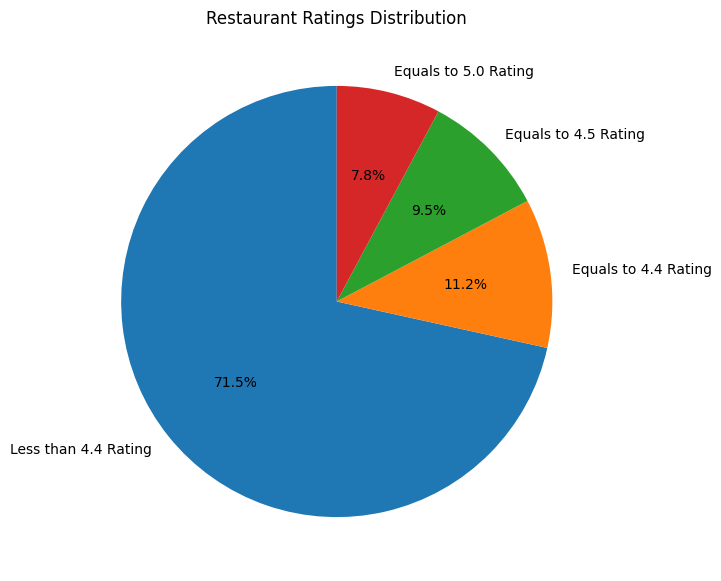

In [ ]:
# Create counts for each category
result= (df['Rating'] < 4.4).sum()
result1 = (df['Rating'] == 4.4).sum()
result2 = (df['Rating'] == 4.5).sum()
result3= (df['Rating'] == 5.0).sum()

# Store in lists
labels = ['Less than 4.4 Rating', 'Equals to 4.4 Rating', 'Equals to 4.5 Rating', 'Equals to 5.0 Rating']
sizes = [result, result1, result2, result3]

plt.figure(figsize=(7,7))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Restaurant Ratings Distribution')
plt.show()

In [ ]:
# Filter restaurant with cost >= 5000
filtered_cost = df[df['Cost'] >= 5000]
# Sort by rating in descending order
sorted_cost = filtered_cost.sort_values(by='Cost', ascending=False)

# Display the result
result_cost= sorted_cost[['Name', 'Cost']]
result_cost
result_cost_df= result_cost.reset_index(drop=True)
result_cost_df

,Name,Cost
0,Masque,8000
1,Kheer,6000
2,Le Cirque,5000
3,The Qube,5000
4,Megu,5000
5,Sevilla,5000
6,Del,5000
7,Chi Ni,5000
8,Masala Library by Jiggs Kalra,5000
9,Seasonal Tastes,5000


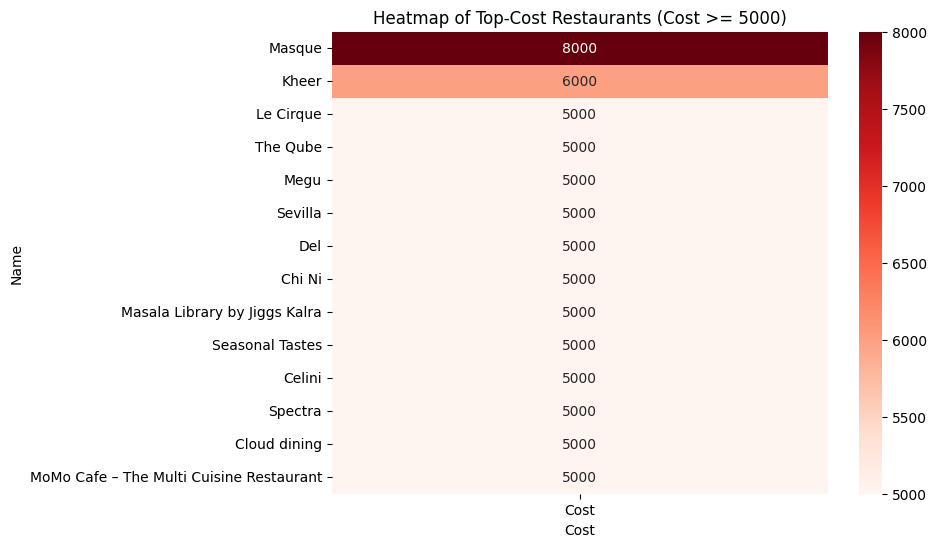

In [ ]:
#Setting restaurant_name as index for plotting
heatmap_data = result_cost_df.set_index('Name')
#Ploting heatmap
plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Reds",
    cbar=True)
plt.title("Heatmap of Top-Cost Restaurants (Cost >= 5000)")
plt.ylabel("Name")
plt.xlabel("Cost")
plt.show()

In [ ]:
# Filter restaurants with votes < 1000
filtered_restaurants_votes1 = df[df['Votes']< 1000]
filtered_restaurants_votes1

,Name,Location,Locality,City,Cuisine,Rating,Votes,Cost
7,QBA,"Connaught Place, Central Delhi",Central Delhi,Delhi,"Multi-Cuisine, North Indian, Italian, Conti...",4.3,963,2100
8,My Bar Square,"Connaught Place, Central Delhi",Central Delhi,Delhi,"Finger Food, Italian, Chinese, Continental",3.9,506,1500
9,Ghoomar Traditional Thali Restaurant,"Connaught Place, Central Delhi",Central Delhi,Delhi,Rajasthani,4.2,712,1000
12,Padmanabham,"Janpath, Central Delhi",Central Delhi,Delhi,South Indian,4.2,223,700
16,Sandoz,"Connaught Place, Central Delhi",Central Delhi,Delhi,"North Indian, Chinese, Mughlai",4.2,134,1500
...,...,...,...,...,...,...,...,...
6588,Shree Rathnam,"Wave Mall,BRS Nagar, West Ludhiana",West Ludhiana,Ludhiana,South Indian,4.1,20,600
6589,Cafe Delish,"Radisson Blu,Rajguru Nagar, West Ludhiana",West Ludhiana,Ludhiana,"Multi-Cuisine, North Indian, Continental, A...",4.4,48,3100
6590,3 K Resorts,"BRS Nagar, West Ludhiana",West Ludhiana,Ludhiana,North Indian,1.0,1,1100
6591,Dovka Bar,"Nirvana Hotel Banquets Club,PAU, Central Ludhiana",Central Ludhiana,Ludhiana,"North Indian, Chinese, Finger Food",4.3,3,1500


In [ ]:
# Filter restaurant with votes >= 1000
filtered_votes = df[df['Votes'] >= 1000]
# Sort by votes in descending order
sorted_votes = filtered_votes.sort_values(by='Votes', ascending=False)

# Display the result
result_votes= sorted_votes[['Name', 'Votes']]
result_votes
result_votes_df= result_votes.reset_index(drop=True)
result_votes_df

,Name,Votes
0,Tamasha,5016
1,Boa Village,4265
2,Byg Brewski Brewing Company,3500
3,AIR An Ivory Region,3270
4,TOS - Take Off Scarlet,3055
...,...,...
93,Hammered,1038
94,The Luggage Room By Sandoz,1022
95,I Sacked Newton,1014
96,Roots,1013


/tmp/ipykernel_6152/2583877792.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


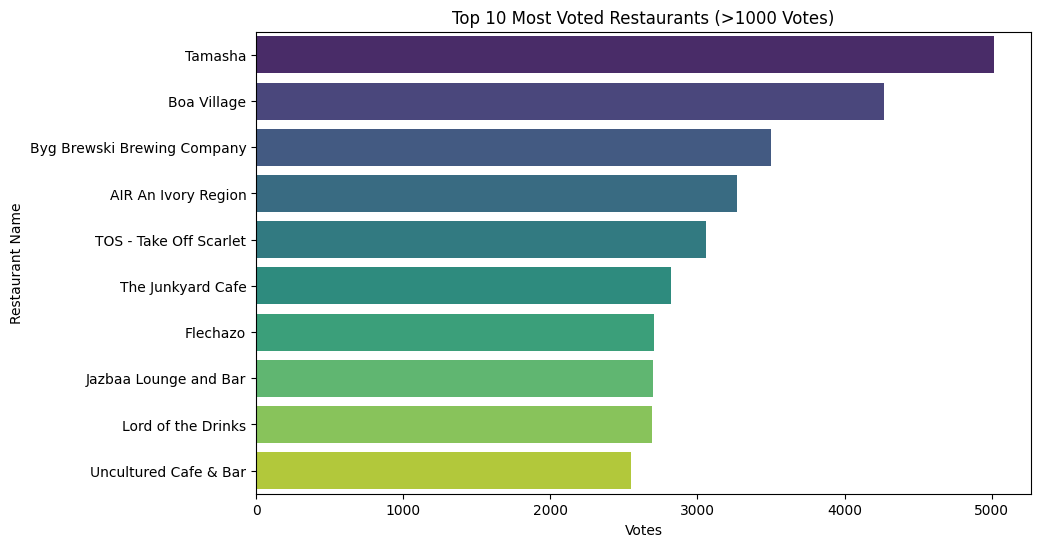

In [ ]:
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Vote_Category'] = df['Votes'].apply(
    lambda x: '<1000' if x < 1000 else ('1000' if x == 1000 else '>1000')
)
high_votes_df = df[df['Vote_Category'] == '>1000']
top10 = high_votes_df.sort_values(by='Votes', ascending=False).head(10)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Votes',
    y='Name',
    palette='viridis'
)

plt.title('Top 10 Most Voted Restaurants (>1000 Votes)')
plt.xlabel('Votes')
plt.ylabel('Restaurant Name')

plt.show()

In [ ]:
# Count of restaurants per cuisine
df['Cuisine'].value_counts()

,count
Cuisine,
"North Indian, Chinese",294
Fast Food,167
North Indian,150
"North Indian, Chinese, Continental",146
"North Indian, Mughlai",128
...,...
"South Indian, Mangalorean, Coastal, Seafood",1
"Desserts, Drinks, Fast Food",1
"Tibetan, Chinese, Seafood",1


In [ ]:
cuisines_to_check = ['Chinese','Italian','North Indian','South Indian','Multi-Cuisine','Asian','Continental','Mexican','American','Mediterranean']
counts = df[df['Cuisine'].isin(cuisines_to_check)]['Cuisine'].value_counts()
print(counts)

Cuisine
North Indian     150
South Indian      88
Chinese           41
Italian           24
Continental       16
Mexican           12
Asian             11
Multi-Cuisine     11
American           7
Mediterranean      3
Name: count, dtype: int64


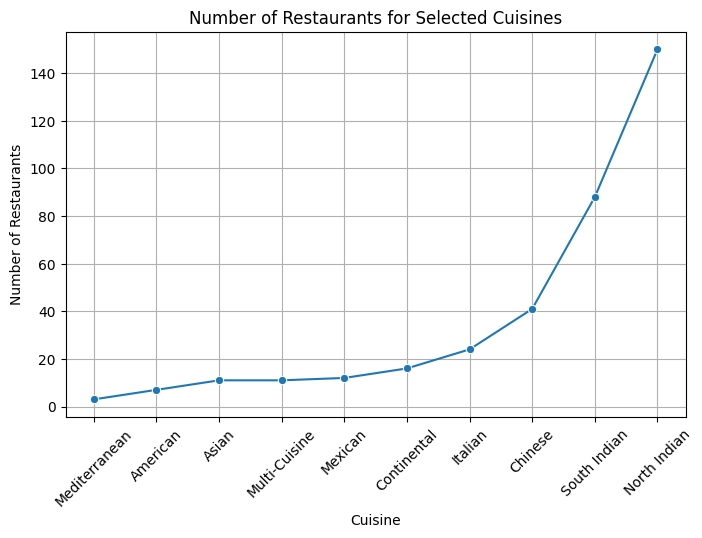

In [108]:
# List of cuisines to plot
selected_cuisines = ['Chinese','Italian','North Indian','South Indian','Multi-Cuisine','Asian','Continental','Mexican','American','Mediterranean']

# Filter the dataframe to only these cuisines
filtered_df = df[df['Cuisine'].isin(selected_cuisines)]

# Count number of restaurants for each selected cuisine
cuisine_counts = filtered_df['Cuisine'].value_counts().reset_index()
cuisine_counts.columns = ['Cuisine', 'Count']

# Optional: sort by count
cuisine_counts = cuisine_counts.sort_values(by='Count')

plt.figure(figsize=(8,5))

sns.lineplot(
    data=cuisine_counts,
    x='Cuisine',
    y='Count',
    marker='o'  # show points on the line
)

plt.xticks(rotation=45)
plt.title('Number of Restaurants for Selected Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Number of Restaurants')
plt.grid(True)
plt.show()